### `SplitODEProblem_test.ipynb`
*Created: October 7, 2026* <br/>
This notebook implements some of the ETD-Runge-Kutta methods from the `OrdinaryDiffEqExponentialRK.jl` package.

In [1]:
using OrdinaryDiffEqExponentialRK, SciMLOperators
import OrdinaryDiffEqCore: OrdinaryDiffEqAlgorithm  
using CairoMakie

In [2]:
#EXAMPLE 1: Van der Pol oscillator
function vdp_nonlin(u,p,t)
    return [0.0, -p*(u[1])^2 * u[2]]
end 

p = 10.0
A_vdp = [0.0 1.0; -1.0 p] 
u0 = [2.0, 0.0]

vanderpol = SplitODEProblem(MatrixOperator(A_vdp), vdp_nonlin, u0, (0.0, 50.0), p);

sol = solve(vanderpol, ETDRK3(); dt = 0.05);

In [35]:
fieldnames(typeof(vanderpol))

(:f, :u0, :tspan, :p, :kwargs, :problem_type)

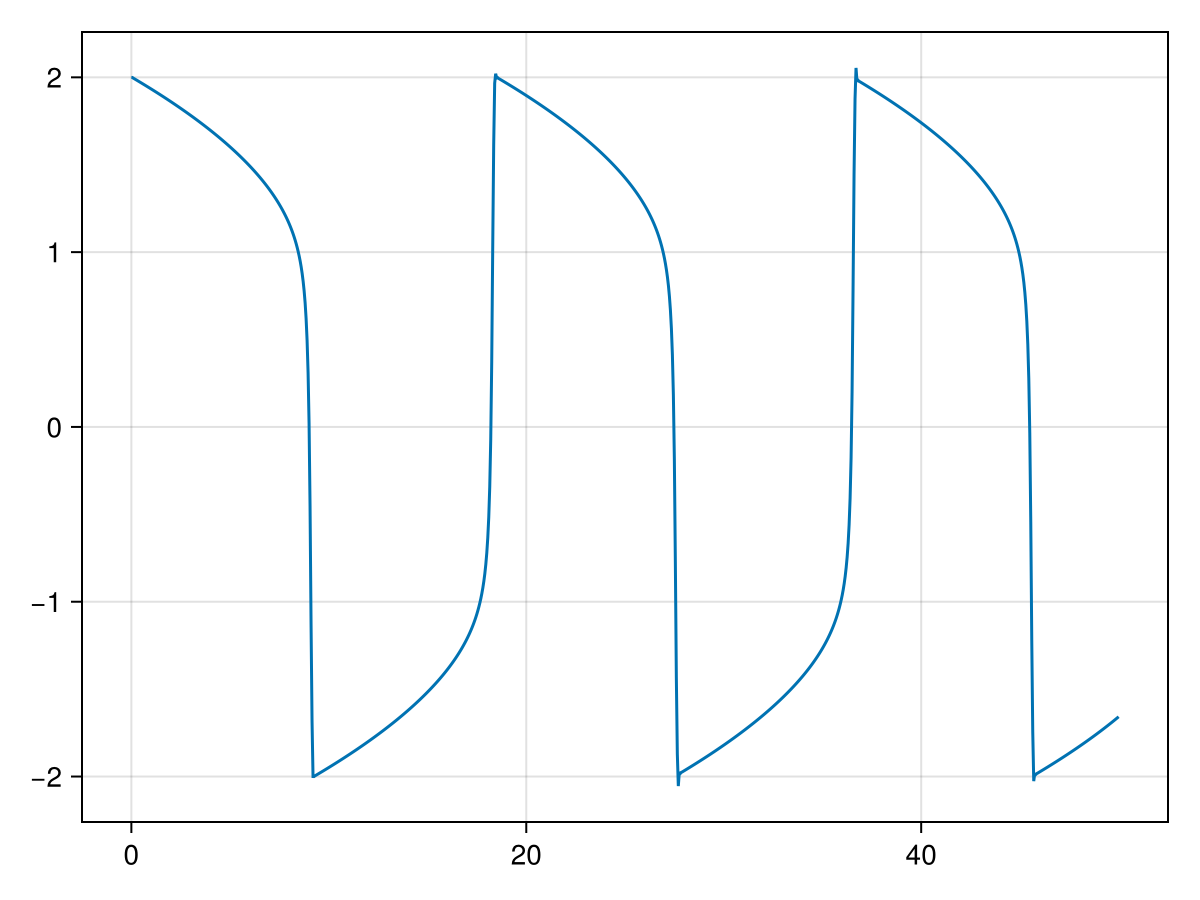

CairoMakie.Screen{IMAGE}


In [31]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(sol.t, getindex.(sol.u, 1))
display(fig)